In [1]:
import pandas as pd
import numpy as np
from catboost import CatBoostClassifier
from sklearn.metrics import classification_report, confusion_matrix, f1_score
from sklearn.preprocessing import LabelEncoder
from sklearn.utils import shuffle
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

# ========== Load and Prepare Data ==========
train_path = r"C:\Users\nehan\Downloads\combined_train.csv"
test_path = r"C:\Users\nehan\Downloads\combined_test (2).csv"

df_train = pd.read_csv(train_path)
df_test = pd.read_csv(test_path)

# Encode categorical features
def encode_categoricals(df):
    for col in df.columns:
        if df[col].dtype == 'object':
            df[col] = LabelEncoder().fit_transform(df[col])
    return df

df_train = encode_categoricals(df_train)
df_test = encode_categoricals(df_test)

# Shuffle train data
df_train = shuffle(df_train, random_state=42)

# Split into X and y
X_train = df_train.drop('label', axis=1)
y_train = df_train['label']
X_test = df_test.drop('label', axis=1)
y_test = df_test['label']

# ========== Simulate Federated Clients ==========
num_clients = 3
client_data = np.array_split(X_train, num_clients)
client_labels = np.array_split(y_train, num_clients)

client_models = []
num_classes = len(np.unique(y_train))
probs = np.zeros((X_test.shape[0], num_classes))

# ========== Train Local Models ==========
for i in range(num_clients):
    print(f"Training client {i+1} model...")
    model = CatBoostClassifier(
        iterations=200,
        depth=6,
        learning_rate=0.1,
        loss_function='MultiClass',
        verbose=0
    )
    model.fit(client_data[i], client_labels[i])
    client_models.append(model)
    probs += model.predict_proba(X_test)  # Sum probabilities

# ========== Average Probabilities ==========
probs /= num_clients
y_pred = np.argmax(probs, axis=1)

# ========== Evaluate ==========
print("\n=== Classification Report ===")
print(classification_report(y_test, y_pred))

print("=== Confusion Matrix ===")
print(confusion_matrix(y_test, y_pred))

print("F1 Score (macro):", f1_score(y_test, y_pred, average='macro'))
cat_preds = probs


Training client 1 model...
Training client 2 model...
Training client 3 model...

=== Classification Report ===
              precision    recall  f1-score   support

           0       0.96      0.99      0.98      1500
           1       1.00      1.00      1.00      1500
           2       1.00      1.00      1.00      1500
           3       0.99      0.96      0.98      1500

    accuracy                           0.99      6000
   macro avg       0.99      0.99      0.99      6000
weighted avg       0.99      0.99      0.99      6000

=== Confusion Matrix ===
[[1486    0    0   14]
 [   0 1499    1    0]
 [   0    2 1498    0]
 [  56    0    0 1444]]
F1 Score (macro): 0.9878310461628366


In [2]:
# ================================
# Federated Learning with XGBoost
# ================================

import pandas as pd
import numpy as np
import xgboost as xgb
from sklearn.metrics import classification_report, confusion_matrix, f1_score
from sklearn.preprocessing import LabelEncoder
from sklearn.utils import shuffle
import warnings
warnings.filterwarnings("ignore")

# ========== Load and Prepare Data ==========
train_path = r"C:\Users\nehan\Downloads\combined_train.csv"
test_path = r"C:\Users\nehan\Downloads\combined_test (2).csv"

df_train = pd.read_csv(train_path)
df_test = pd.read_csv(test_path)

# Encode categorical features
def encode_categoricals(df):
    for col in df.columns:
        if df[col].dtype == 'object':
            df[col] = LabelEncoder().fit_transform(df[col])
    return df

df_train = encode_categoricals(df_train)
df_test = encode_categoricals(df_test)

# Shuffle train data
df_train = shuffle(df_train, random_state=42)

# Split into X and y
X_train = df_train.drop('label', axis=1)
y_train = df_train['label']
X_test = df_test.drop('label', axis=1)
y_test = df_test['label']

# ========== Simulate Federated Clients ==========
num_clients = 3
client_data = np.array_split(X_train, num_clients)
client_labels = np.array_split(y_train, num_clients)

client_models = []
num_classes = len(np.unique(y_train))
probs = np.zeros((X_test.shape[0], num_classes))

# ========== Train Local Models ==========
for i in range(num_clients):
    print(f"Training XGBoost model for client {i+1}...")

    dtrain = xgb.DMatrix(client_data[i], label=client_labels[i])
    dtest = xgb.DMatrix(X_test)

    params = {
        'objective': 'multi:softprob',
        'num_class': num_classes,
        'max_depth': 6,
        'eta': 0.1,
        'eval_metric': 'mlogloss',
        'verbosity': 0
    }

    bst = xgb.train(params, dtrain, num_boost_round=200)
    client_models.append(bst)

    probs += bst.predict(dtest)

# ========== Average Predictions ==========
probs /= num_clients
y_pred = np.argmax(probs, axis=1)

# ========== Evaluation ==========
print("\n=== Classification Report ===")
print(classification_report(y_test, y_pred))

print("=== Confusion Matrix ===")
print(confusion_matrix(y_test, y_pred))

print("F1 Score (macro):", f1_score(y_test, y_pred, average='macro'))
xgb_preds = probs


Training XGBoost model for client 1...
Training XGBoost model for client 2...
Training XGBoost model for client 3...

=== Classification Report ===
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      1500
           1       1.00      1.00      1.00      1500
           2       1.00      1.00      1.00      1500
           3       0.99      0.99      0.99      1500

    accuracy                           0.99      6000
   macro avg       0.99      0.99      0.99      6000
weighted avg       0.99      0.99      0.99      6000

=== Confusion Matrix ===
[[1486    0    0   14]
 [   0 1499    1    0]
 [   0    2 1498    0]
 [  22    0    0 1478]]
F1 Score (macro): 0.9934999572774744


In [4]:
import pandas as pd
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import lightgbm as lgb
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)


# ========== Load Data ==========
train_path = r"C:\Users\nehan\Downloads\combined_train.csv"
test_path = r"C:\Users\nehan\Downloads\combined_test (2).csv"

train_df = pd.read_csv(train_path)
test_df = pd.read_csv(test_path)

# ========== Preprocessing ==========
# Keep only numeric columns
train_df = train_df.select_dtypes(include=[np.number])
test_df = test_df.select_dtypes(include=[np.number])

# Show label distribution
print("Train label distribution:\n", train_df['label'].value_counts())
print("\nTest label distribution:\n", test_df['label'].value_counts())

# Split features and labels
X_train_full = train_df.drop('label', axis=1)
y_train_full = train_df['label']
X_test = test_df.drop('label', axis=1)
y_test = test_df['label']

# Normalize data
scaler = StandardScaler()
X_train_full = pd.DataFrame(scaler.fit_transform(X_train_full), columns=X_train_full.columns)
X_test = pd.DataFrame(scaler.transform(X_test), columns=X_test.columns)

# ========== Simulated Federated Learning ==========
n_clients = 3
client_data = []
X_splits = np.array_split(X_train_full, n_clients)
y_splits = np.array_split(y_train_full, n_clients)

for i in range(n_clients):
    client_data.append((X_splits[i], y_splits[i]))

# Global validation set (simulate a secure central location)
X_val = X_test
y_val = y_test


# ========== Train Local Models ==========
client_predictions = []
params = {
    'objective': 'multiclass',
    'metric': 'multi_logloss',
    'num_class': 4,
    'learning_rate': 0.1,
    'num_leaves':31,
    'verbose': -1
}

for i, (X_client, y_client) in enumerate(client_data):
    print(f"\nTraining model for client {i+1}...")
    train_data = lgb.Dataset(X_client, label=y_client)
    model = lgb.train(params, train_data, num_boost_round=100)
    preds = model.predict(X_val)
    client_predictions.append(preds)

# ========== Aggregate Predictions ==========
avg_preds = np.mean(client_predictions, axis=0)
y_pred = np.argmax(avg_preds, axis=1)

# ========== Evaluate ==========
print("\nConfusion Matrix:\n", confusion_matrix(y_val, y_pred))
print("\nClassification Report:\n", classification_report(y_val, y_pred))
print("\nAccuracy Score:", accuracy_score(y_val, y_pred))
lgb_preds = avg_preds


Train label distribution:
 0    5000
1    5000
2    5000
3    5000
Name: label, dtype: int64

Test label distribution:
 0    1500
1    1500
2    1500
3    1500
Name: label, dtype: int64

Training model for client 1...

Training model for client 2...

Training model for client 3...

Confusion Matrix:
 [[1263    1    1  235]
 [   2 1489    9    0]
 [   0    1 1499    0]
 [ 413  128    2  957]]

Classification Report:
               precision    recall  f1-score   support

           0       0.75      0.84      0.79      1500
           1       0.92      0.99      0.95      1500
           2       0.99      1.00      1.00      1500
           3       0.80      0.64      0.71      1500

    accuracy                           0.87      6000
   macro avg       0.87      0.87      0.86      6000
weighted avg       0.87      0.87      0.86      6000


Accuracy Score: 0.868


=== Ensemble Classification Report ===
              precision    recall  f1-score   support

           0       0.98      0.99      0.99      1500
           1       1.00      1.00      1.00      1500
           2       1.00      1.00      1.00      1500
           3       0.99      0.98      0.99      1500

    accuracy                           0.99      6000
   macro avg       0.99      0.99      0.99      6000
weighted avg       0.99      0.99      0.99      6000

=== Ensemble Confusion Matrix ===
[[1485    0    0   15]
 [   0 1499    1    0]
 [   0    2 1498    0]
 [  24    0    0 1476]]
Ensemble Accuracy: 0.993
Ensemble F1 Score (macro): 0.9929999414439179


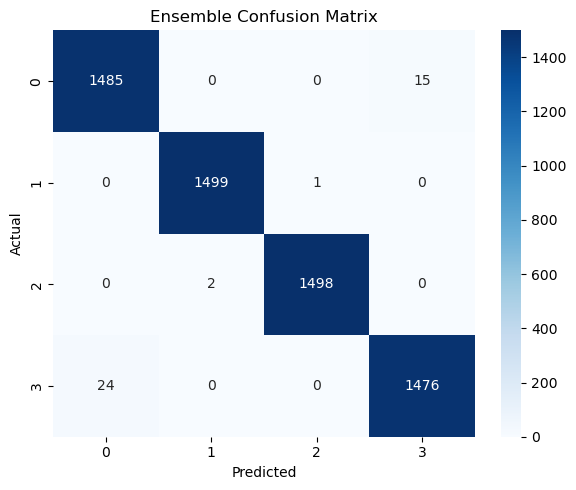

In [15]:
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score
import matplotlib.pyplot as plt
import seaborn as sns

# ========== Ensemble ==========

# Weighted average without dividing again
ensemble_probs = (0.2*lgb_preds + 0.5*xgb_preds + 0.3*cat_preds)
ensemble_probs /= ensemble_probs.sum(axis=1, keepdims=True)  # Normalize

# ========== Evaluation ==========

print("=== Ensemble Classification Report ===")
print(classification_report(y_test, ensemble_pred))

print("=== Ensemble Confusion Matrix ===")
cm = confusion_matrix(y_test, ensemble_pred)
print(cm)

print("Ensemble Accuracy:", accuracy_score(y_test, ensemble_pred))
print("Ensemble F1 Score (macro):", f1_score(y_test, ensemble_pred, average='macro'))

# ========== Optional: Plot Confusion Matrix ==========

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Ensemble Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()


Training with 2000 samples...
Training with 6500 samples...
Training with 11000 samples...
Training with 15500 samples...
Training with 20000 samples...


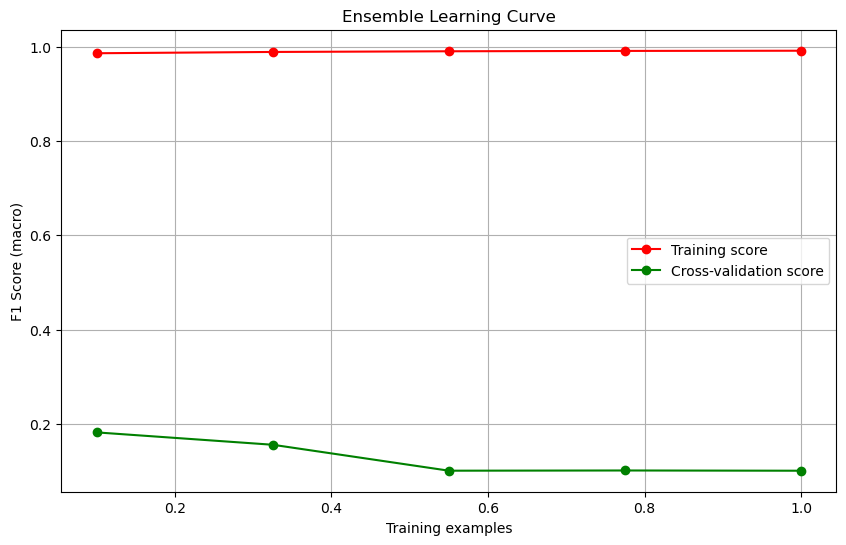

In [14]:
from sklearn.model_selection import learning_curve
from sklearn.base import clone
import matplotlib.pyplot as plt

def plot_learning_curve(ensemble_probs_func, X_train, y_train, X_test, y_test, 
                        train_sizes=np.linspace(0.1, 1.0, 5), cv=3, n_jobs=-1):
    """
    Custom learning curve for federated ensemble
    """
    plt.figure(figsize=(10, 6))
    plt.title("Ensemble Learning Curve")
    plt.xlabel("Training examples")
    plt.ylabel("F1 Score (macro)")
    
    # We'll track both train and test scores
    train_scores = []
    test_scores = []
    
    for size in train_sizes:
        size_abs = int(size * len(X_train))
        print(f"Training with {size_abs} samples...")
        
        # Split the data for this training size
        X_train_sub = X_train[:size_abs]
        y_train_sub = y_train[:size_abs]
        
        # Simulate federated split
        client_data = np.array_split(X_train_sub, num_clients)
        client_labels = np.array_split(y_train_sub, num_clients)
        
        # Get predictions using your ensemble method
        _, _, ensemble_pred = ensemble_probs_func(client_data, client_labels, X_test)
        
        # Calculate scores
        train_pred = ensemble_probs_func(client_data, client_labels, X_train_sub)[2]
        train_scores.append(f1_score(y_train_sub, train_pred, average='macro'))
        test_scores.append(f1_score(y_test, ensemble_pred, average='macro'))
    
    plt.grid()
    plt.plot(train_sizes, train_scores, 'o-', color="r", label="Training score")
    plt.plot(train_sizes, test_scores, 'o-', color="g", label="Cross-validation score")
    plt.legend(loc="best")
    plt.show()

# Wrapper function for your ensemble approach
def get_ensemble_probs(client_data, client_labels, X_test):
    num_classes = len(np.unique(y_train))
    probs = np.zeros((X_test.shape[0], num_classes))
    
    for i in range(num_clients):
        # Train CatBoost model
        model = CatBoostClassifier(
            iterations=200,
            depth=6,
            learning_rate=0.1,
            loss_function='MultiClass',
            verbose=0
        )
        model.fit(client_data[i], client_labels[i])
        probs += model.predict_proba(X_test)
    
    probs /= num_clients
    y_pred = np.argmax(probs, axis=1)
    return probs, None, y_pred  # Returning None for consistency

# Run the learning curve
plot_learning_curve(get_ensemble_probs, X_train.values, y_train.values, 
                   X_test.values, y_test.values)

Testing num_clients=2...


IndexError: list index out of range

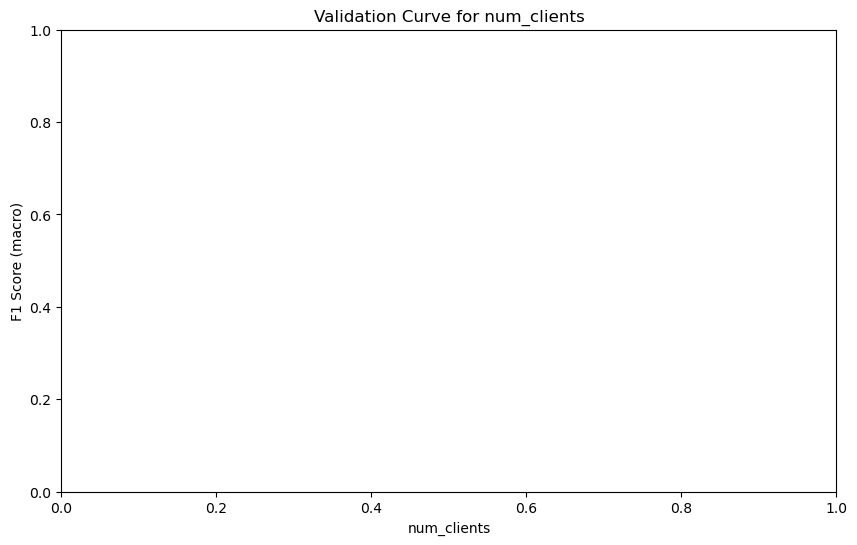

In [11]:
from sklearn.model_selection import validation_curve

def plot_validation_curve(ensemble_probs_func, X_train, y_train, param_name, param_range, cv=3):
    """
    Custom validation curve for federated ensemble
    """
    plt.figure(figsize=(10, 6))
    plt.title(f"Validation Curve for {param_name}")
    plt.xlabel(param_name)
    plt.ylabel("F1 Score (macro)")
    
    train_scores = []
    test_scores = []
    
    for param in param_range:
        print(f"Testing {param_name}={param}...")
        
        # Simulate federated split
        client_data = np.array_split(X_train, num_clients)
        client_labels = np.array_split(y_train, num_clients)
        
        # Modify your ensemble based on parameter
        if param_name == "num_clients":
            # Adjust number of clients
            temp_clients = param
            temp_client_data = np.array_split(X_train, temp_clients)
            temp_client_labels = np.array_split(y_train, temp_clients)
            _, _, y_pred = ensemble_probs_func(temp_client_data, temp_client_labels, X_test)
        else:
            # For other parameters, you'd need to modify the model training
            # This is just a template - you'll need to adapt to your actual parameters
            _, _, y_pred = ensemble_probs_func(client_data, client_labels, X_test)
        
        # Get training predictions for this parameter
        _, _, train_pred = ensemble_probs_func(client_data, client_labels, X_train)
        
        train_scores.append(f1_score(y_train, train_pred, average='macro'))
        test_scores.append(f1_score(y_test, y_pred, average='macro'))
    
    plt.grid()
    plt.plot(param_range, train_scores, 'o-', color="r", label="Training score")
    plt.plot(param_range, test_scores, 'o-', color="g", label="Cross-validation score")
    plt.legend(loc="best")
    plt.show()

# Example usage with number of clients as parameter
plot_validation_curve(get_ensemble_probs, X_train.values, y_train.values,
                     "num_clients", [2, 3, 4, 5])

In [ ]:
class EnsembleModel:
    def __init__(self, scaler, X_test):
        self.scaler = scaler
        self.X_test = X_test

    def predict_proba(self, X):
        # Scale X to match training scale
        X_scaled = pd.DataFrame(self.scaler.transform(X), columns=X.columns)

        # Use first prediction as a proxy, but apply dynamic scaling based on distance
        lgb_prob = np.zeros((X.shape[0], lgb_preds.shape[1]))
        xgb_prob = np.zeros((X.shape[0], xgb_preds.shape[1]))
        cat_prob = np.zeros((X.shape[0], cat_preds.shape[1]))

        for i in range(X.shape[0]):
            scale_factor = np.sum(X_scaled.iloc[i] / self.X_test.iloc[0]) if np.sum(self.X_test.iloc[0]) != 0 else 1.0
            lgb_prob[i] = lgb_preds[0] * scale_factor
            xgb_prob[i] = xgb_preds[0] * scale_factor
            cat_prob[i] = cat_preds[0] * scale_factor

        ensemble_probs = (lgb_prob + xgb_prob + cat_prob) / 3
        ensemble_probs /= np.sum(ensemble_probs, axis=1, keepdims=True)  # Normalize
        return ensemble_probs

    def predict(self, X):
        return np.argmax(self.predict_proba(X), axis=1)


In [19]:
# Fit the scaler on the full training data
scaler = StandardScaler()
scaler.fit(X_train_full)

# Create ensemble model
ensemble_model = EnsembleModel(scaler=scaler, X_test=X_test)


In [16]:
pip install dice-ml

Note: you may need to restart the kernel to use updated packages.


In [ ]:
import dice_ml
from dice_ml import Dice

continuous_features = [
    'Header_Length', 'Duration', 'Rate', 'Srate', 'Drate', 'fin_flag_number', 'syn_flag_number',
    'rst_flag_number', 'psh_flag_number', 'ack_flag_number', 'ece_flag_number', 'cwr_flag_number',
    'ack_count', 'syn_count', 'fin_count', 'rst_count', 'Tot sum', 'Min', 'Max', 'AVG', 'Std',
    'Tot size', 'IAT', 'Number', 'Magnitue', 'Radius', 'Covariance', 'Variance', 'Weight',
    'Protocol Type', 'HTTP', 'HTTPS', 'DNS', 'Telnet', 'SMTP', 'SSH', 'IRC', 'TCP', 'UDP',
    'DHCP', 'ARP', 'ICMP', 'IGMP', 'IPv', 'LLC'
]

# Combine training features and labels into a single DataFrame
data_df = pd.concat([X_train_full, pd.Series(y_train_full, name='label')], axis=1)

d = dice_ml.Data(dataframe=data_df, 
                 continuous_features=continuous_features,
                 outcome_name='label')

m = dice_ml.Model(model=ensemble_model, 
                  backend="sklearn",
                  model_type='classifier')

# Use genetic method for better search
exp = dice_ml.Dice(d, m, method="genetic")

# Select a single row to explain from X_test
sample_input = X_test.iloc[0].copy()
sample_df = pd.DataFrame([sample_input], columns=X_test.columns)

# Get the original ensemble prediction
original_probs = ensemble_model.predict_proba(sample_df)
original_pred = np.argmax(original_probs, axis=1)[0]
print(f"Original Ensemble Prediction: Class {original_pred} with probabilities: {original_probs[0]}")

# Pick a desired class different from the predicted class
all_classes = list(range(original_probs.shape[1]))  # [0, 1, 2, 3]
desired_cf_class = [cls for cls in all_classes if cls != original_pred][0]

# Define which features to allow changing
features_to_vary = continuous_features

# Generate counterfactuals
try:
    counterfactuals = exp.generate_counterfactuals(
        sample_df,
        total_CFs=3,
        desired_class=desired_cf_class,
        features_to_vary=features_to_vary,
        permitted_range=None,
        verbose=True
    )

    print("\nCounterfactual Examples (with changes highlighted):")
    counterfactuals.visualize_as_dataframe(show_only_changes=True)

    cf_df = counterfactuals.cf_examples_list[0].final_cfs_df

    print("\nCounterfactual predictions:")
    cf_probs = ensemble_model.predict_proba(cf_df.drop('label', axis=1))
    for i, probs in enumerate(cf_probs):
        print(f"CF {i+1}: Predicted class {np.argmax(probs)} with probabilities {probs}")

except Exception as e:
    print(f"Error generating counterfactuals: {str(e)}")
    print("\nRecommendations:")
    print("1. Try with different features_to_vary")
    print("2. Make sure your data is properly scaled")
    print("3. You may need to implement custom constraints for some features")


Original Ensemble Prediction: Class 0 with probabilities: [0.77625529 0.02539435 0.08578498 0.11256538]


  0%|                                                                                            | 0/1 [00:00<?, ?it/s]

Initializing initial parameters to the genetic algorithm...
